# Part 1: Neural Network Fundamentals and Training Behavior Analysis
## Customer Churn Prediction - Feed-Forward Neural Network

**Dataset:** `customer_churn_nn.csv` | **Target:** `churn` (1 = churned, 0 = retained) | **Library:** TensorFlow / Keras


---
## Task 1: Dataset Understanding


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('customer_churn_nn.csv')

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")
print()
print("Columns and data types:")
print(df.dtypes.to_string())


  DATASET OVERVIEW
  Rows    : 2000
  Columns : 17

Columns and data types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64


In [ ]:
# First 5 rows
df.head()


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [ ]:
# Missing value check
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing >= 0].to_string())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")


Missing values per column:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0

Total missing cells: 0


In [ ]:
# Statistical summary
df.describe().round(2)


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.00,2000.00,2000.0,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,25.36,766.49,18.1,1.95,3.56,90.01,6.87,46.62,8.26,0.60,0.92,0.02
std,14.13,393.42,5.4,1.46,3.89,53.22,1.52,55.07,7.55,0.49,1.04,0.12
min,1.00,255.45,0.0,0.00,0.00,0.50,1.00,0.00,0.00,0.00,0.00,0.00
25%,15.00,427.78,15.0,1.00,1.00,51.78,5.88,6.00,0.00,0.00,0.00,0.00
50%,23.00,688.36,18.0,2.00,2.00,80.24,6.80,28.50,5.00,1.00,1.00,0.00
75%,33.00,1007.37,22.0,3.00,5.00,119.10,8.00,68.00,15.00,1.00,1.00,0.00
max,72.00,2156.52,30.0,8.00,31.00,265.51,10.00,424.00,20.00,1.00,7.00,1.00


Target variable distribution:
  Retained (0): 1969  (98.5%)
  Churned  (1): 31  (1.6%)


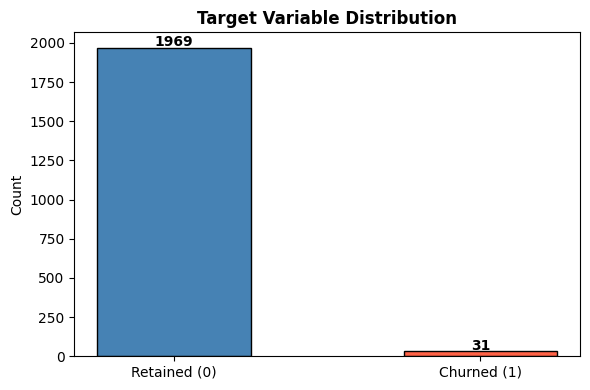

Note: Dataset is highly imbalanced (1.55% churn). Class weighting will be applied during training.


In [ ]:
# Target distribution
churn_counts = df['churn'].value_counts().sort_index()
print("Target variable distribution:")
print(f"  Retained (0): {churn_counts[0]}  ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"  Churned  (1): {churn_counts[1]}  ({churn_counts[1]/len(df)*100:.1f}%)")

plt.figure(figsize=(6, 4))
plt.bar(['Retained (0)', 'Churned (1)'], churn_counts.values,
        color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
plt.title('Target Variable Distribution', fontweight='bold')
plt.ylabel('Count')
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Note: Dataset is highly imbalanced (1.55% churn). Class weighting will be applied during training.")


---
## Task 2: Data Preprocessing


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

df_model = df.drop(columns=['customer_id'])

# Encode categorical columns
cat_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nAll categorical columns encoded.")


region: {'Central': np.int64(0), 'East': np.int64(1), 'North': np.int64(2), 'South': np.int64(3), 'West': np.int64(4)}
plan_type: {'Basic': np.int64(0), 'Enterprise': np.int64(1), 'Premium': np.int64(2), 'Standard': np.int64(3)}
contract_type: {'Month-to-month': np.int64(0), 'One-year': np.int64(1), 'Two-year': np.int64(2)}
payment_method: {'Credit Card': np.int64(0), 'Debit Card': np.int64(1), 'Net Banking': np.int64(2), 'UPI': np.int64(3), 'Wallet': np.int64(4)}

All categorical columns encoded.


In [ ]:
X = df_model.drop(columns=['churn']).values
y = df_model['churn'].values

# Split before scaling to avoid leaking information from the test set.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Feature matrix X: {X.shape}")
print(f"Train : {X_train.shape[0]} samples  (churn rate: {y_train.mean():.4f})")
print(f"Test  : {X_test.shape[0]} samples  (churn rate: {y_test.mean():.4f})")
print(f"Scaled training mean (first 4 features): {X_train.mean(axis=0).round(3)[:4]}")
print(f"Scaled training std  (first 4 features): {X_train.std(axis=0).round(3)[:4]}")


Feature matrix X: (2000, 15)
Train : 1600 samples  (churn rate: 0.0156)
Test  : 400 samples  (churn rate: 0.0150)
Scaled training mean (first 4 features): [-0. -0.  0.  0.]
Scaled training std  (first 4 features): [1. 1. 1. 1.]


---
## Task 3: Neural Network Model Building

Architecture:
- **Input layer**: 15 features
- **Hidden layer 1**: 64 neurons, ReLU
- **Hidden layer 2**: 32 neurons, ReLU
- **Output layer**: 1 neuron, sigmoid activation for binary classification
- **Loss**: Binary cross-entropy
- **Optimizer**: Adam


In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)
np.random.seed(42)

class_vals = np.array([0, 1])
cw_vals = compute_class_weight('balanced', classes=class_vals, y=y_train)
class_weight = {0: float(cw_vals[0]), 1: float(cw_vals[1])}
print(f"Class weights: {class_weight}")
print("High weight on class 1 helps the model pay attention to minority churn samples.")

def build_model(hidden_layers=[(64, 'relu'), (32, 'relu')], lr=0.001):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    for units, activation in hidden_layers:
        model.add(Dense(units, activation=activation))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline = build_model()
baseline.summary()

Class weights: {0: 0.5079365079365079, 1: 32.0}
High weight on class 1 helps the model pay attention to minority churn samples.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

### Learning Process - Step by Step

| Step | Description |
|------|-------------|
| **Forward pass** | Inputs are multiplied by weights, biases are added, activations are applied, and the network outputs a churn probability. |
| **Loss** | Binary cross-entropy/log loss measures the difference between the predicted probability and the true class. |
| **Backpropagation** | Gradients of the loss are propagated backward through the hidden layers to find how each weight and bias contributed to the error. |
| **Update** | Adam updates weights and biases using the gradients and the selected learning rate. |


---
## Task 4: Training and Evaluation - Baseline Model


In [ ]:
model_baseline = build_model(hidden_layers=[(64, 'relu'), (32, 'relu')], lr=0.001)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model_baseline.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

print(f"Training stopped at epoch {len(history.history['loss'])}")

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7194 - loss: 0.7545 - val_accuracy: 0.6750 - val_loss: 0.6582
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7049 - loss: 0.6204 - val_accuracy: 0.6500 - val_loss: 0.6513
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7319 - loss: 0.5570 - val_accuracy: 0.6625 - val_loss: 0.6185
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7646 - loss: 0.5006 - val_accuracy: 0.7312 - val_loss: 0.5666
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7979 - loss: 0.4520 - val_accuracy: 0.7750 - val_loss: 0.5145
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8250 - loss: 0.4089 - val_accuracy: 0.8000 - val_loss: 0.4702
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8368 - loss: 0.3697 - val_accuracy: 0.8250 - val_loss: 0.4317
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8535 - loss: 0.3353 - val_accuracy: 0.8500 - 

In [ ]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, ConfusionMatrixDisplay,
                             accuracy_score, log_loss)

train_loss, train_acc = model_baseline.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model_baseline.evaluate(X_test, y_test, verbose=0)

y_pred_prob = model_baseline.predict(X_test, verbose=0).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("=" * 45)
print("  BASELINE MODEL - PERFORMANCE SUMMARY")
print("=" * 45)
print(f"  Training Accuracy : {train_acc:.4f}")
print(f"  Testing  Accuracy : {test_acc:.4f}")
print(f"  Training Loss     : {train_loss:.4f}")
print(f"  Testing  Loss     : {test_loss:.4f}")
print(f"  ROC-AUC Score     : {roc_auc_score(y_test, y_pred_prob):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned'], zero_division=0))

  BASELINE MODEL - PERFORMANCE SUMMARY
  Training Accuracy : 0.9912
  Testing  Accuracy : 0.9575
  Training Loss     : 0.0340
  Testing  Loss     : 0.1387
  ROC-AUC Score     : 0.8321

Classification Report:
              precision    recall  f1-score   support

    Retained       0.99      0.97      0.98       394
     Churned       0.08      0.17      0.11         6

    accuracy                           0.96       400
   macro avg       0.53      0.57      0.54       400
weighted avg       0.97      0.96      0.97       400



In [ ]:
import os
os.makedirs('results', exist_ok=True)

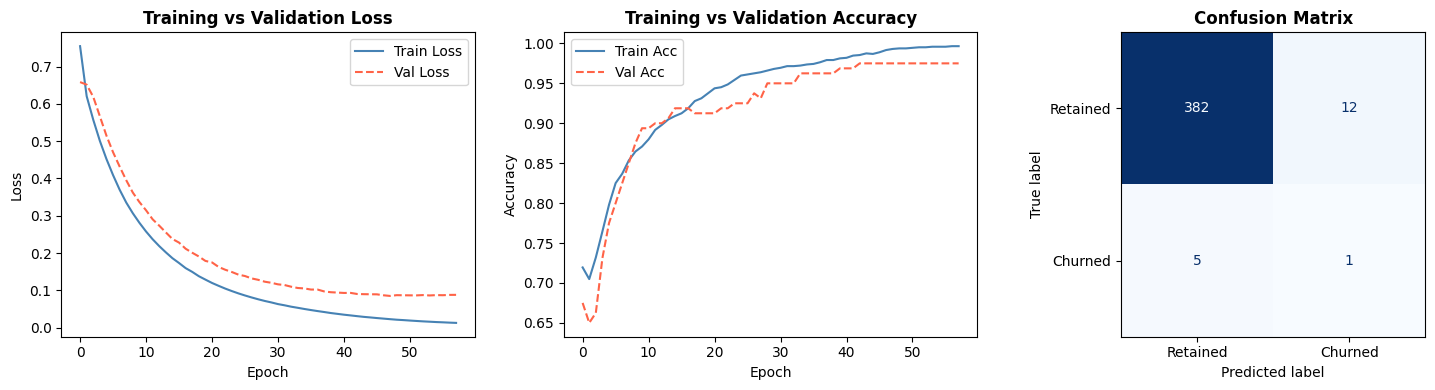

Interpretation: 382 correct retentions, 1 correct churn detections, 5 missed churns (FN), 12 false alarms (FP)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='tomato', linestyle='--')
axes[0].set_title('Training vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Acc', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='tomato', linestyle='--')
axes[1].set_title('Training vs Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned']).plot(
    ax=axes[2], cmap='Blues', colorbar=False
)
axes[2].set_title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Interpretation: {cm[0,0]} correct retentions, {cm[1,1]} correct churn detections, "
      f"{cm[1,0]} missed churns (FN), {cm[0,1]} false alarms (FP)")


---
## Task 5: Hyperparameter Experimentation

Five configurations varying architecture, learning rate, batch size, and activation function.


In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score

experiments = [
    {"name": "Config 1 - Baseline", "hidden_layers": [(64, 'relu'), (32, 'relu')], "lr": 0.001, "batch": 32, "epochs": 100, "desc": "2 layers ReLU, lr=0.001, batch=32"},
    {"name": "Config 2 - Deeper Network", "hidden_layers": [(128, 'relu'), (64, 'relu'), (32, 'relu')], "lr": 0.001, "batch": 32, "epochs": 100, "desc": "3 layers (128->64->32), ReLU, lr=0.001, batch=32"},
    {"name": "Config 3 - High LR", "hidden_layers": [(64, 'relu'), (32, 'relu')], "lr": 0.01, "batch": 32, "epochs": 100, "desc": "2 layers ReLU, lr=0.01, batch=32"},
    {"name": "Config 4 - Low LR", "hidden_layers": [(64, 'relu'), (32, 'relu')], "lr": 0.0001, "batch": 32, "epochs": 100, "desc": "2 layers ReLU, lr=0.0001, batch=32"},
    {"name": "Config 5 - tanh + Large Batch", "hidden_layers": [(64, 'tanh'), (32, 'tanh')], "lr": 0.001, "batch": 128, "epochs": 100, "desc": "2 layers tanh, lr=0.001, batch=128"},
]

results_list = []
all_histories = []

for exp in experiments:
    tf.random.set_seed(42)
    model = build_model(hidden_layers=exp['hidden_layers'], lr=exp['lr'])
    exp_history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=exp['epochs'],
        batch_size=exp['batch'],
        class_weight=class_weight,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    all_histories.append(exp_history)

    tr_loss, tr_acc = model.evaluate(X_train, y_train, verbose=0)
    te_loss, te_acc = model.evaluate(X_test, y_test, verbose=0)
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_hat = (y_prob >= 0.5).astype(int)

    results_list.append({
        "Configuration": exp['name'],
        "Description": exp['desc'],
        "Train Acc": round(tr_acc, 4),
        "Test Acc": round(te_acc, 4),
        "Train Loss": round(tr_loss, 4),
        "Test Loss": round(te_loss, 4),
        "AUC": round(roc_auc_score(y_test, y_prob), 4),
        "F1 (Churn)": round(f1_score(y_test, y_hat, zero_division=0), 4),
        "Recall (Churn)": round(recall_score(y_test, y_hat, zero_division=0), 4),
        "Precision (Churn)": round(precision_score(y_test, y_hat, zero_division=0), 4),
        "Epochs Run": len(exp_history.history['loss']),
    })
    print(f"Done: {exp['name']}")

df_comp = pd.DataFrame(results_list)
print()
print("All experiments complete!")

Done: Config 1 - Baseline
Done: Config 2 - Deeper Network
Done: Config 3 - High LR
Done: Config 4 - Low LR
Done: Config 5 - tanh + Large Batch

All experiments complete!


In [ ]:
# Display and save comparison table
import os
os.makedirs('results', exist_ok=True)

display_cols = [
    'Configuration', 'Train Acc', 'Test Acc', 'Train Loss', 'Test Loss',
    'AUC', 'F1 (Churn)', 'Recall (Churn)', 'Precision (Churn)', 'Epochs Run'
]
df_comp[display_cols].to_csv('results/model_comparison_table.csv', index=False)

df_comp[display_cols].round(4)

,Configuration,Train Acc,Test Acc,Train Loss,Test Loss,AUC,F1 (Churn),Recall (Churn),Precision (Churn),Epochs Run
0,Config 1 - Baseline,0.9962,0.9700,0.0099,0.1710,0.7783,0.1429,0.1667,0.1250,86
1,Config 2 - Deeper Network,0.9987,0.9675,0.0058,0.1782,0.8245,0.1333,0.1667,0.1111,58
2,Config 3 - High LR,0.9944,0.9600,0.0179,0.1750,0.8426,0.1111,0.1667,0.0833,30
3,Config 4 - Low LR,0.8925,0.8950,0.2158,0.2352,0.8634,0.1600,0.6667,0.0909,100
4,Config 5 - tanh + Large Batch,0.9656,0.9275,0.0877,0.1533,0.8997,0.1714,0.5000,0.1034,100


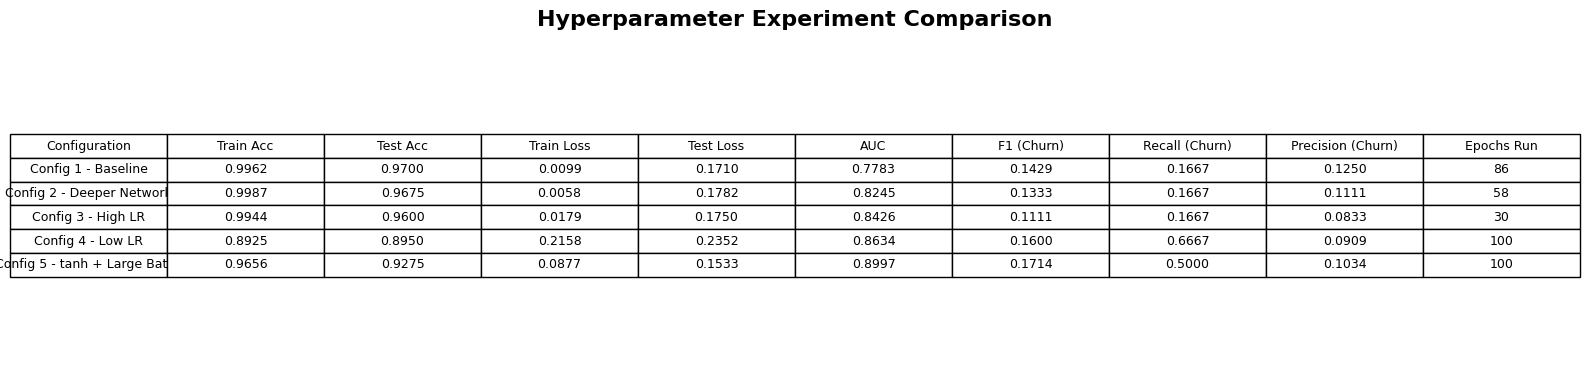

In [ ]:
# Save the comparison table as an image for the required results folder.
table_df = df_comp[display_cols].copy()
for col in table_df.columns:
    if col != 'Configuration':
        table_df[col] = table_df[col].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)

fig, ax = plt.subplots(figsize=(16, 3.8))
ax.axis('off')
table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.35)
ax.set_title('Hyperparameter Experiment Comparison', fontsize=16, fontweight='bold', pad=18)
plt.tight_layout()
plt.savefig('results/model_comparison_table.png', dpi=200, bbox_inches='tight')
plt.show()

---
## Task 6: Final Reflection

### 1. Role of Weights and Biases

**Weights** control how strongly each input feature influences a neuron. During training, backpropagation updates weights so the model gives more useful importance to predictive features.

**Biases** shift the neuron's activation threshold. They let the model fit patterns that do not pass through zero. A neuron can be summarized as `activation(weighted inputs + bias)`.

---

### 2. Why Activation Functions Are Required

Without activation functions, multiple neural-network layers collapse into one linear transformation. Activation functions add non-linearity, allowing the model to learn more complex decision boundaries.

ReLU is used in the baseline because it is simple, fast, and helps reduce vanishing-gradient problems. The experiments also compare tanh to observe how a different activation changes performance.

---

### 3. Effect of Learning Rate

A learning rate that is too high can make updates jump past a good solution, causing unstable training or poor accuracy. A learning rate that is too low makes training very slow, so the model may underfit within the selected epoch limit. The comparison table shows how changing learning rate affects loss, AUC, recall, and F1.

---

### 4. Underfitting vs. Overfitting

The main challenge in this dataset is class imbalance: very few customers churn. Accuracy can look high even when the model misses churned customers, so ROC-AUC, recall, precision, and F1 are more meaningful than accuracy alone.

The model does not show severe overfitting if training and testing accuracy/loss remain close. A high learning rate may cause unstable learning, while a very low learning rate may underfit because the model learns too slowly. The best configuration should be selected from the comparison table based on the metric that matters most: recall if missing churned customers is costly, or F1 if both false alarms and missed churners matter.
